# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

1. In quantum mechanics, the Hamiltonian is the operator that represents the total energy of a system. It usually includes both kinetic energy and potential energy, so it is often written as H(hat) = V(hat) + T(hat) (I could not get these symbols to work properly). T(hat) is the kinetic energy operator and V(hat) is the potential energy operator. The Hamiltonian is important because solving the Schrodinger equation with the Hamiltonian gives the allowed energy levels and wavefunctions of the system. In the qmsolve harmonic oscillator code, the 'Hamiltonian' class sets up this energy operator for a particle in the harmonic oscillator potential, then solves for its eigenstates and corresponding energy values.
    Sources: https://chem.libretexts.org/Courses/Pacific_Union_College/Quantum_Chemistry/04%3A_Postulates_and_Principles_of_Quantum_Mechanics/4.02%3A_Quantum_Operators_Represent_Classical_Variables
https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics)

2.  The function harmonic_oscillator() defines the potential energy of a particle in a harmonic oscillator. It uses the equation V(x) = 0.5k x^2, meaning the potential energy increases as the particle moves farther away from the center position. This aligns with Hooke’s law because the particle experiences a restoring force that pulls it back toward equilibrium, and that force gets stronger as the displacement increases.

3. Eigenstates are the specific allowed wave functions of a quantum system that correspond to definite energy values. In this code, the Hamiltonian is solved to find the harmonic oscillator’s allowed energy states and their matching wave functions. Each eigenstate represents one possible standing-wave-like state of the particle in the harmonic oscillator potential, and each one has its own energy level.
    Sources: https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors
https://en.wikipedia.org/wiki/Quantum_state

4. (see code)


In [9]:
import sys
!{sys.executable} -m pip install qmsolve


  Preparing metadata (setup.py) ... done
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12067 sha256=fe793ea6fd6a699eab25302deee1076367afab7f8ffe27ed4c67f57b6d6c981c
  Stored in directory: /Users/jakewolhar/Library/Caches/pip/wheels/a5/4d/c7/f3cf0f75c746c219090060131fe00f1523cc2c5484991f4030
Successfully built progressbar


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.035852909088134766
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


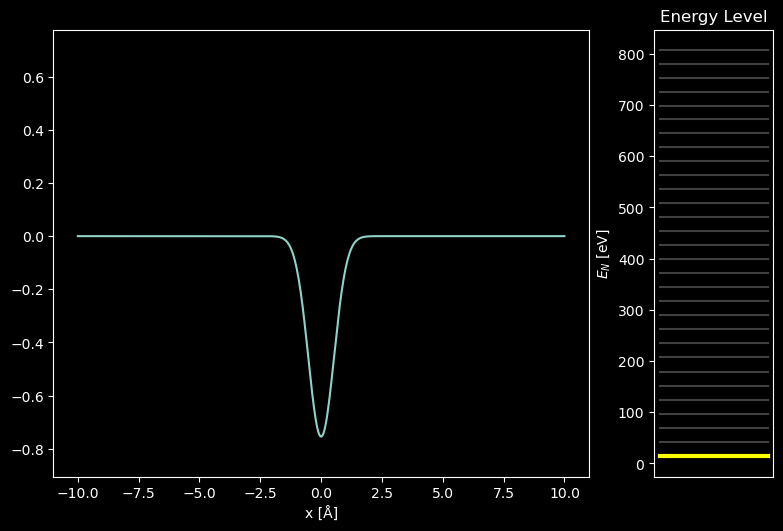

In [13]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

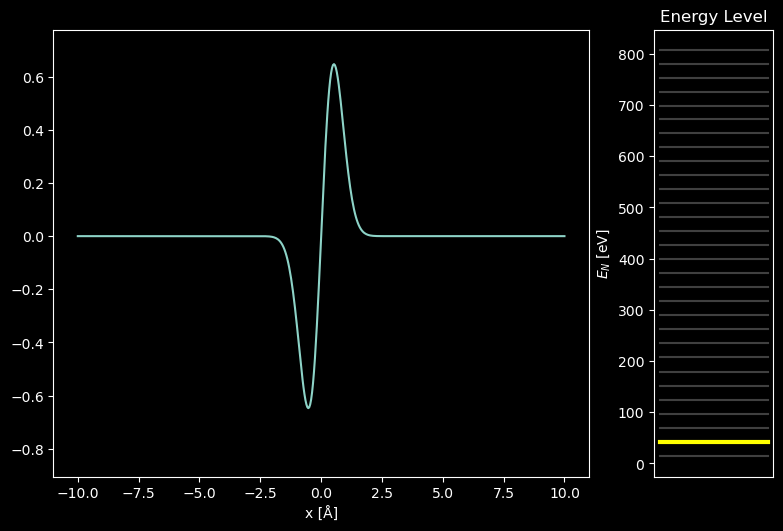

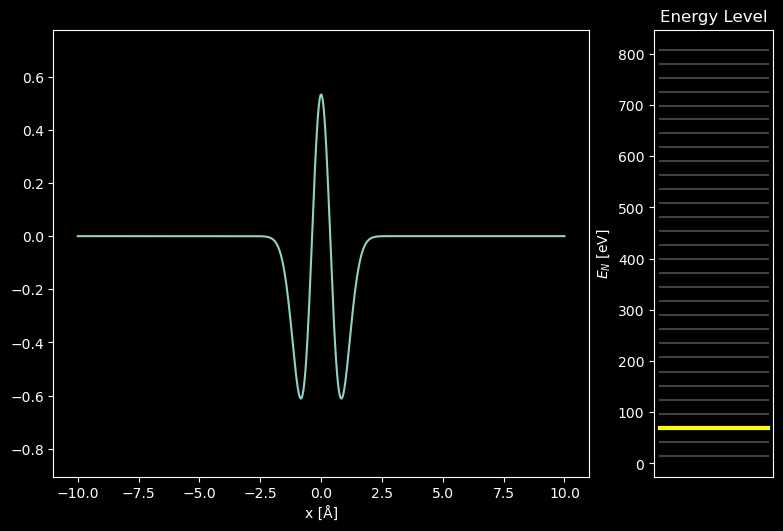

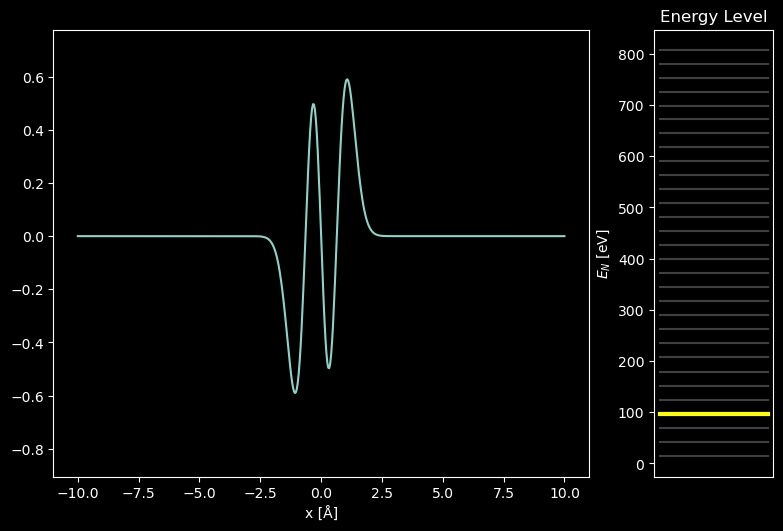

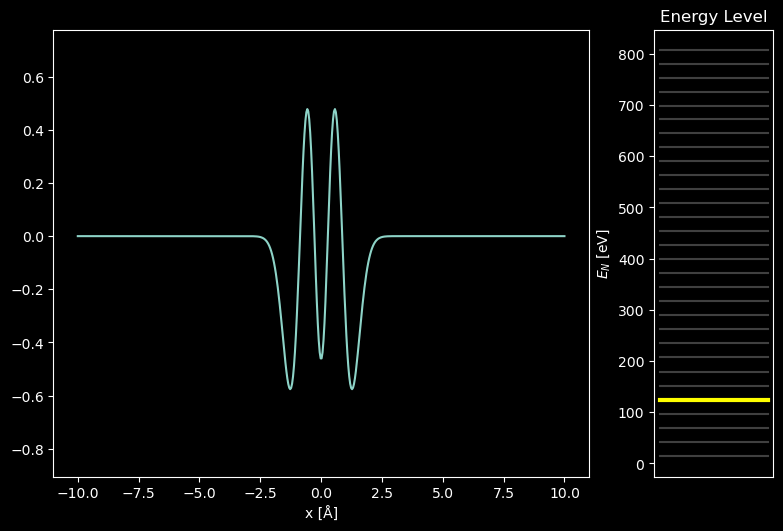

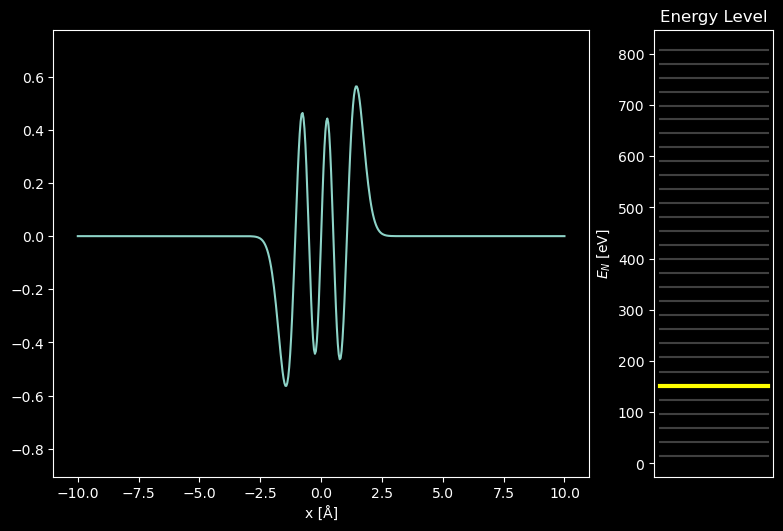

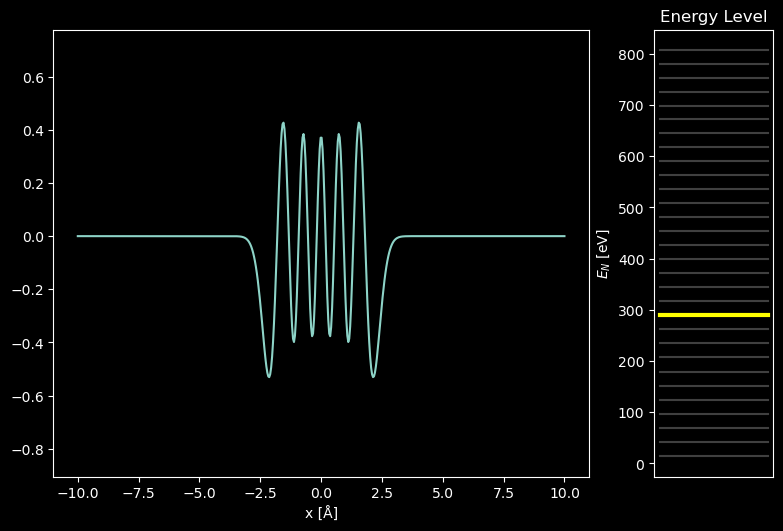

In [19]:
# 4
# Plot five simple harmonic oscillator eigenstates
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(2)
visualization.plot_eigenstate(3)
visualization.plot_eigenstate(4)
visualization.plot_eigenstate(5)
# Bonus!
visualization.plot_eigenstate(10)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

5. The x-axis shows the particle’s position, labeled as x[A], where A represents angstroms. In the graph, the position ranges roughly from -10 A to +10 A, and the plot shows how the eigenstate changes across the 1D space used in the simulation.

6. The plots are showing the wave functions, psi(x), not the probability functions, psi*(x)psi(x). We know this because the plotted values can be negative, as shown by the curve dipping below zero. A probability function cannot be negative, since probability density must always be greater than zero. 

Computing...
Took 0.025039196014404297
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


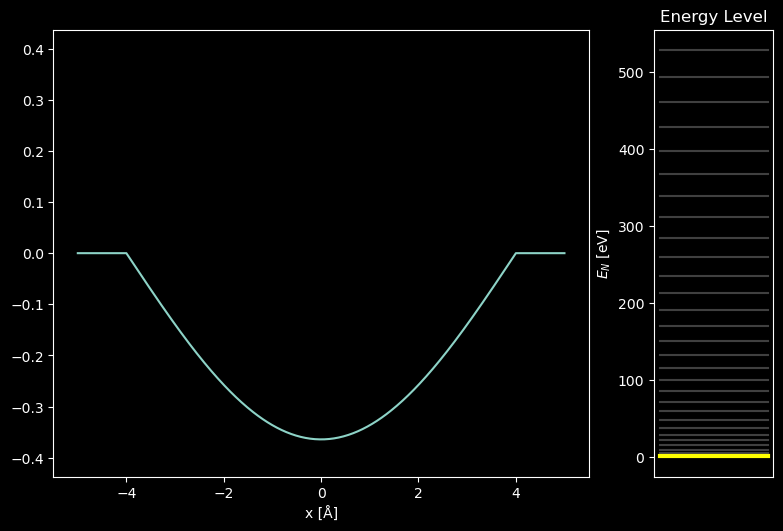

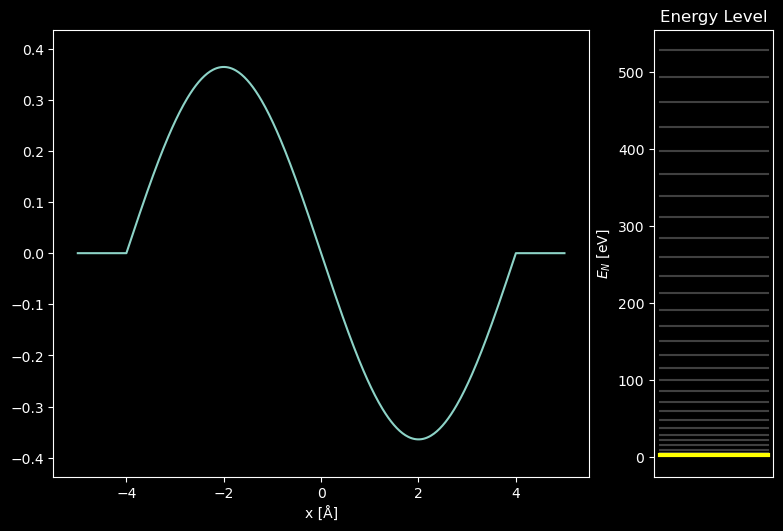

In [21]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

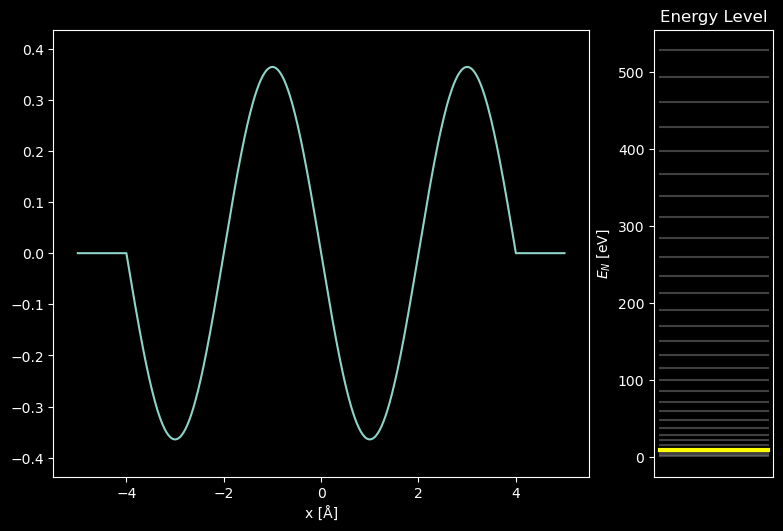

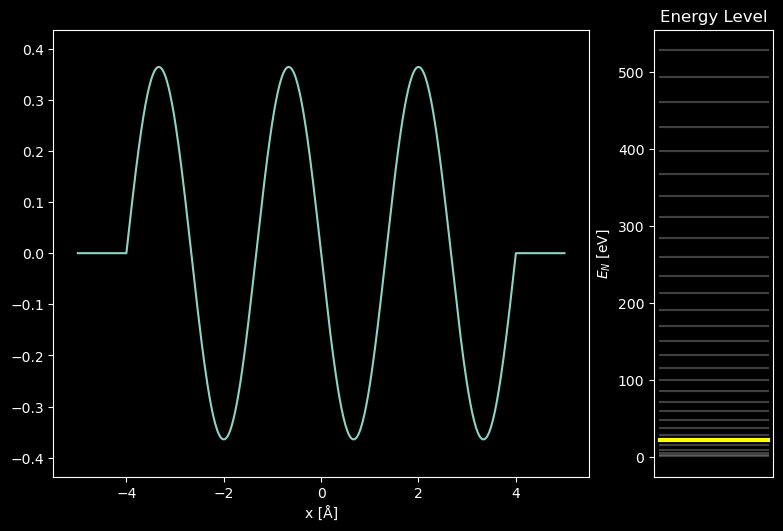

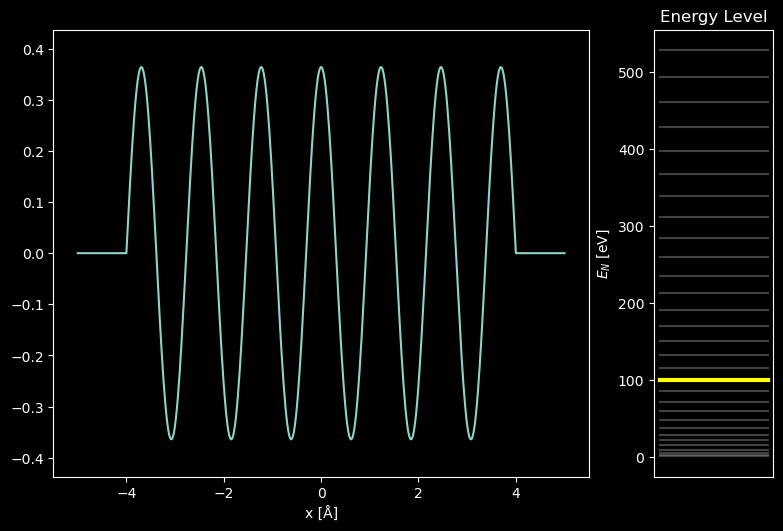

In [23]:
# Question 7

visualization_sw.plot_eigenstate(3)
visualization_sw.plot_eigenstate(5)
visualization_sw.plot_eigenstate(12)

8. The infinite square well eigenstates must go exactly to zero at the walls of the box, because the particle cannot exist outside the well. This is different from the SHO eigenstates, which smoothly taper off as you move away from the center but do not suddenly hit zero at hard boundaries. In terms of valid wave functions, the infinite square well states are forced to satisfy strict boundary conditions at the edges, while the SHO states are smooth, continuous, normalizable functions that gradually approach zero far from the center.

9. For the infinite square well, the number of extrema in each eigenstate increases as the quantum number increases. The first eigenstate (starting at 0) has one extremum, the second has two extrema, the third has three extrema, and so on. In general, the eigenstate with quantum number n has n extrema if you start counting the lowest-energy state as n = 1. This happens because higher-energy states fit more oscillations inside the well.

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.025175809860229492
[  0.53803872   2.15158316   4.83888034   8.59687598  13.42099002
  19.3047426   26.23914444  34.21168625  43.20459372  53.19162646
  64.13172021  75.95502756  88.52835074 101.55842594 114.32016055
 125.37305797 134.41418043 144.34611226 157.42339255 172.80926808
 189.20594928 205.79649393 222.1353246  238.37322185 255.27661393
 273.58579849 293.46023361 314.60112929 336.57991836 359.00942014]


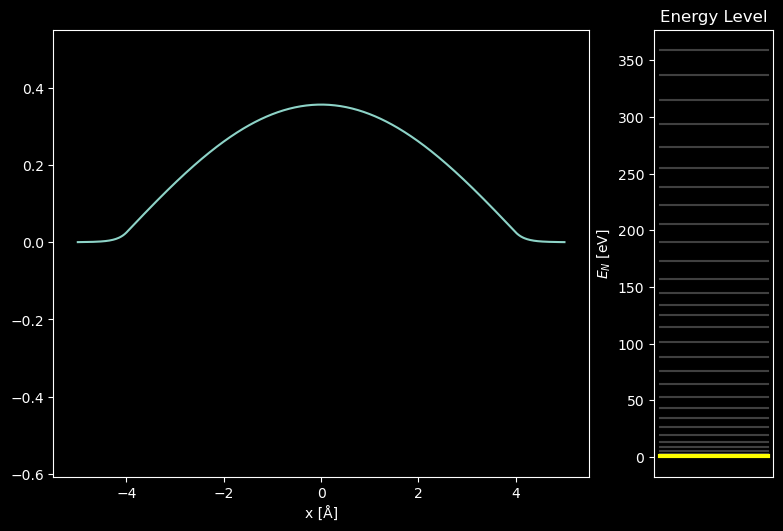

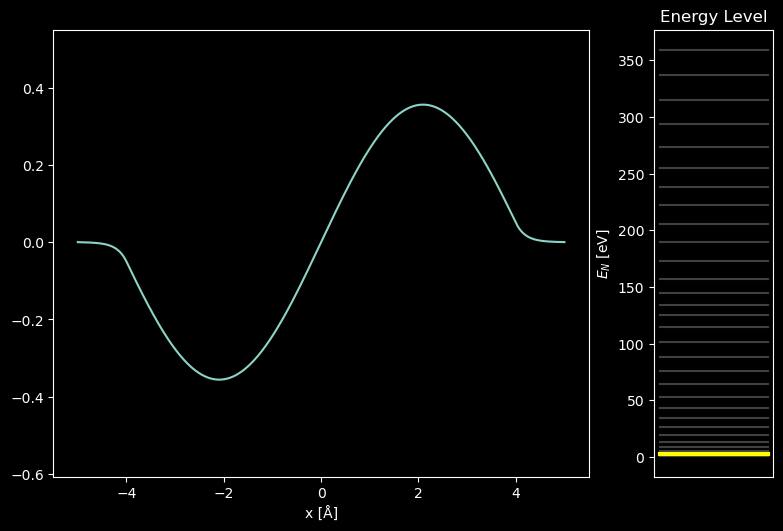

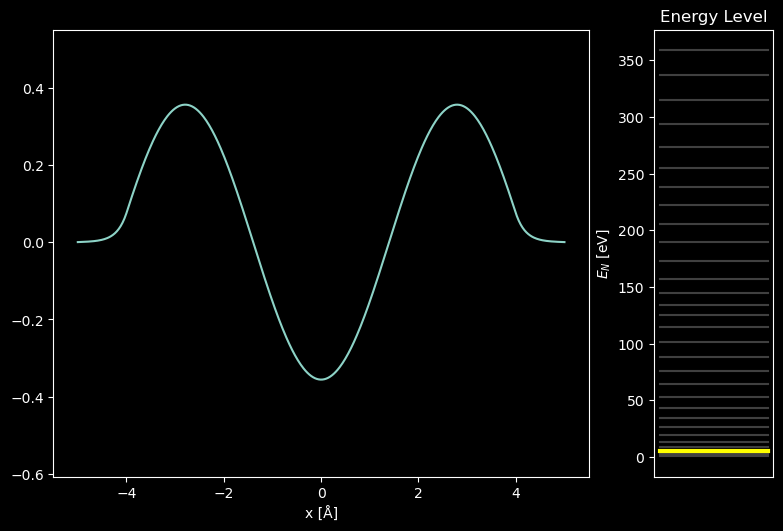

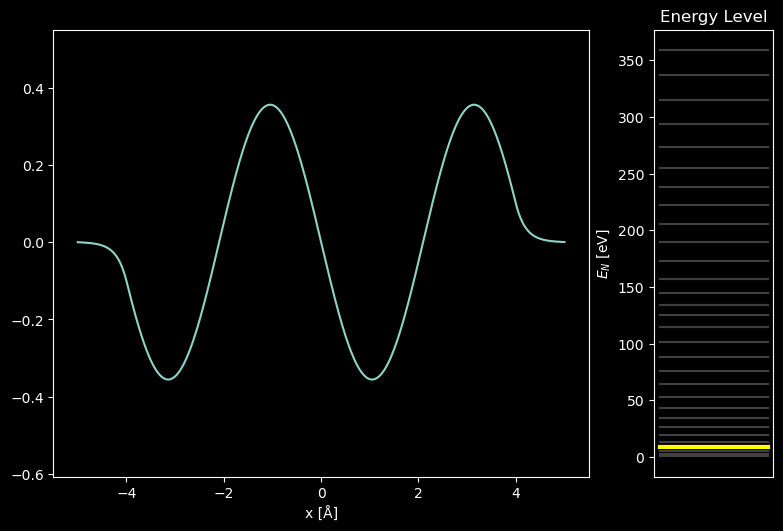

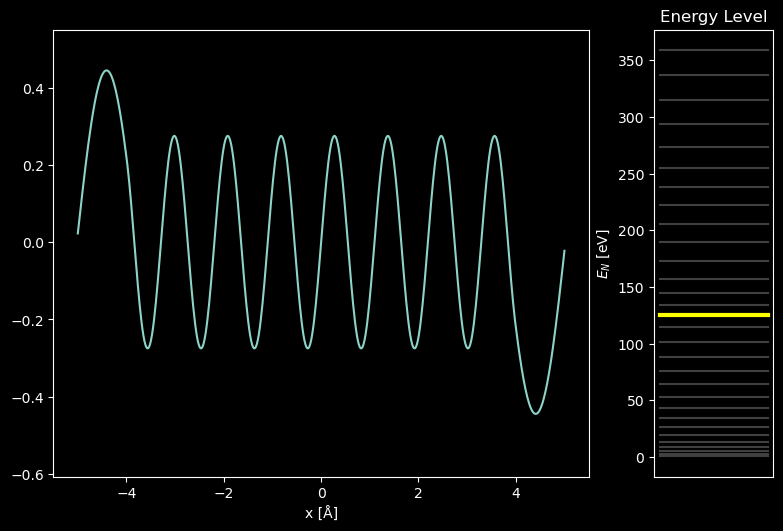

In [27]:
# Question 10

# Finite square well potential
def finite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = 100*eV
    return potential

# Define Hamiltonian of the finite square well
H_fsw = Hamiltonian(particles = SingleParticle(), potential = finite_square_well,
                    spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize Hamiltonian and calc eigenstates
eigenstates_fsw = H_fsw.solve(max_states = 30)

print(eigenstates_fsw.energies)

# Plot five finite square well eigenstates
visualization_fsw = init_visualization(eigenstates_fsw)
visualization_fsw.plot_eigenstate(0)
visualization_fsw.plot_eigenstate(1)
visualization_fsw.plot_eigenstate(2)
visualization_fsw.plot_eigenstate(3)
visualization_fsw.plot_eigenstate(15)

11. While I do think it is possible for a particle to get out of the finite square-well potential, the quantum number n is very important in determining that likelyhood. For the lower-energy states shown in these plots, the particle is mostly trapped in the finite square well, although its wave function slightly extends into the barrier regions. That means there is some probability of finding it just outside the well, but it is still in a bound state and does not fully escape. However, as n increases, the particle’s energy increases, and once its energy is higher than the finite barrier height, it would no longer be trapped in the same way and could easily get out of the well.